In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import sobel, gaussian_filter


 # HARRIS CORNER DETECTOR

In [18]:
def harris_corners_from_scratch(gray_img, block_size=3, ksize=3, k=0.04, threshold_ratio=0.01):
    """
    Harris Corner Detector implemented from scratch using NumPy.
    Detects corners by analyzing intensity changes in two directions.
    """

    # -------------------- STEP 1: IMAGE GRADIENTS --------------------

    Ix = sobel(gray_img, axis=1, mode='constant')  
    # Computes horizontal intensity change (∂I/∂x)
    # High value → strong left-right intensity variation

    Iy = sobel(gray_img, axis=0, mode='constant')  
    # Computes vertical intensity change (∂I/∂y)
    # High value → strong up-down intensity variation


    # -------------------- STEP 2: GRADIENT PRODUCTS --------------------

    Ixx = Ix * Ix   # Square of horizontal gradient → measures strength of x-direction change

    Iyy = Iy * Iy    # Square of vertical gradient → measures strength of y-direction change

    Ixy = Ix * Iy    # Product of x and y gradients → measures correlation between directions


    # -------------------- STEP 3: GAUSSIAN SMOOTHING --------------------

    Ixx = gaussian_filter(Ixx, sigma=1)   # Smooths Ixx to reduce noise and improve stability

    Iyy = gaussian_filter(Iyy, sigma=1)  # Smooths Iyy for robust gradient aggregation

    Ixy = gaussian_filter(Ixy, sigma=1)  # Smooths Ixy to avoid false corner responses


    # -------------------- STEP 4: STRUCTURE TENSOR SUMMATION --------------------

    Sxx = np.zeros_like(gray_img, dtype=np.float32)   # Will store sum of Ixx values inside local window
    Syy = np.zeros_like(gray_img, dtype=np.float32)  
    Sxy = np.zeros_like(gray_img, dtype=np.float32)  

    half = block_size // 2    # Half window size for neighborhood calculation

    for y in range(half, gray_img.shape[0] - half):
        for x in range(half, gray_img.shape[1] - half):

            window_xx = Ixx[y-half:y+half+1, x-half:x+half+1]   # Extracts local Ixx values around current pixel
            window_yy = Iyy[y-half:y+half+1, x-half:x+half+1]  
            window_xy = Ixy[y-half:y+half+1, x-half:x+half+1]  
          
            Sxx[y, x] = np.sum(window_xx)      # Sums horizontal gradient energy in the neighborhood
            Syy[y, x] = np.sum(window_yy)  
            Sxy[y, x] = np.sum(window_xy)  
            # Sums mixed gradient energy in the neighborhood


    # -------------------- STEP 5: HARRIS RESPONSE CALCULATION --------------------

    det_M = Sxx * Syy - Sxy * Sxy  
    # Determinant of structure tensor → λ₁ × λ₂

    trace_M = Sxx + Syy  
    # Trace of structure tensor → λ₁ + λ₂

    R = det_M - k * (trace_M ** 2)  
    # Harris corner response function
    # High positive value → strong corner


    # -------------------- STEP 6: THRESHOLDING --------------------

    max_response = np.max(R)   # Finds strongest corner response in the image
    corner_mask = R > threshold_ratio * max_response    # Keeps only points with response above threshold


    # -------------------- STEP 7: NON-MAXIMUM SUPPRESSION --------------------

    corners = []  
    # List to store final corner points

    for y in range(1, R.shape[0] - 1):
        for x in range(1, R.shape[1] - 1):

            if corner_mask[y, x]:  
                # Checks if pixel passed threshold

                neighborhood = R[y-1:y+2, x-1:x+2]  
                # 3×3 neighborhood around current pixel

                if R[y, x] == np.max(neighborhood):  
                    # Keeps only local maximum response

                    corners.append((y, x))  
                    # Stores (row, column) of detected corner

    return corners  
    # Returns list of all detected Harris corners


# FAST DETECTOR

In [19]:
def fast_corners_from_scratch(gray_img, threshold=25, n=12):
    """
    FAST (Features from Accelerated Segment Test) corner detector.
    Uses simple intensity comparisons for very fast corner detection.
    """

    if gray_img.dtype != np.uint8:
        gray_img = gray_img.astype(np.uint8)
        # Ensures image is in uint8 format (FAST works on intensity values 0–255)


    height, width = gray_img.shape
    # Extracts image height and width

    corners = []
    # List to store detected corner coordinates


    # -------------------- FAST CIRCLE DEFINITION --------------------

    circle = [
        (0, 3), (1, 3), (2, 2), (3, 1),
        (3, 0), (3, -1), (2, -2), (1, -3),
        (0, -3), (-1, -3), (-2, -2), (-3, -1),
        (-3, 0), (-3, 1), (-2, 2), (-1, 3)
    ]
    # 16 pixel positions on a Bresenham circle of radius 3
    # These are the pixels compared against the center pixel


    # -------------------- SCAN IMAGE (AVOID BORDERS) --------------------

    for y in range(3, height - 3):
        # Starts from 3 to avoid accessing pixels outside the image

        for x in range(3, width - 3):
            # Scans each valid pixel position

            center = int(gray_img[y, x])
            # Stores intensity value of the center pixel


            # -------------------- INITIALIZE COUNTERS --------------------

            brighter = 0 # Counts total brighter pixels (not mandatory, for understanding)
            darker = 0
            consec_bright = 0 # Tracks current consecutive brighter pixels
            consec_dark = 0 
            max_consec_b = 0 # Stores maximum consecutive brighter pixels found

            max_consec_d = 0 # Stores maximum consecutive darker pixels found


            # -------------------- INTENSITY COMPARISON --------------------

            for dx, dy in circle:
                # Iterates over all 16 circle pixels

                p = int(gray_img[y + dy, x + dx])
                # Gets intensity of current circle pixel


                if p > center + threshold:
                    # Pixel is significantly brighter than center

                    brighter += 1          # Increase brighter pixel count
                    consec_bright += 1     # Increase consecutive brighter sequence
                    consec_dark = 0        # Reset darker sequence

                    max_consec_b = max(max_consec_b, consec_bright)      # Update maximum bright sequence length


                elif p < center - threshold:
                    # Pixel is significantly darker than center

                    darker += 1
                    consec_dark += 1               
                    consec_bright = 0
                    max_consec_d = max(max_consec_d, consec_dark)
            

                else:
                    consec_bright = 0
                    consec_dark = 0
        


            # -------------------- CORNER DECISION --------------------

            if max_consec_b >= n or max_consec_d >= n:
                corners.append((y, x))
                # Mark current pixel as a FAST corner


    return corners


# Demonstration

Running Harris Corner Detector (from scratch)...
Running FAST Corner Detector (from scratch)...


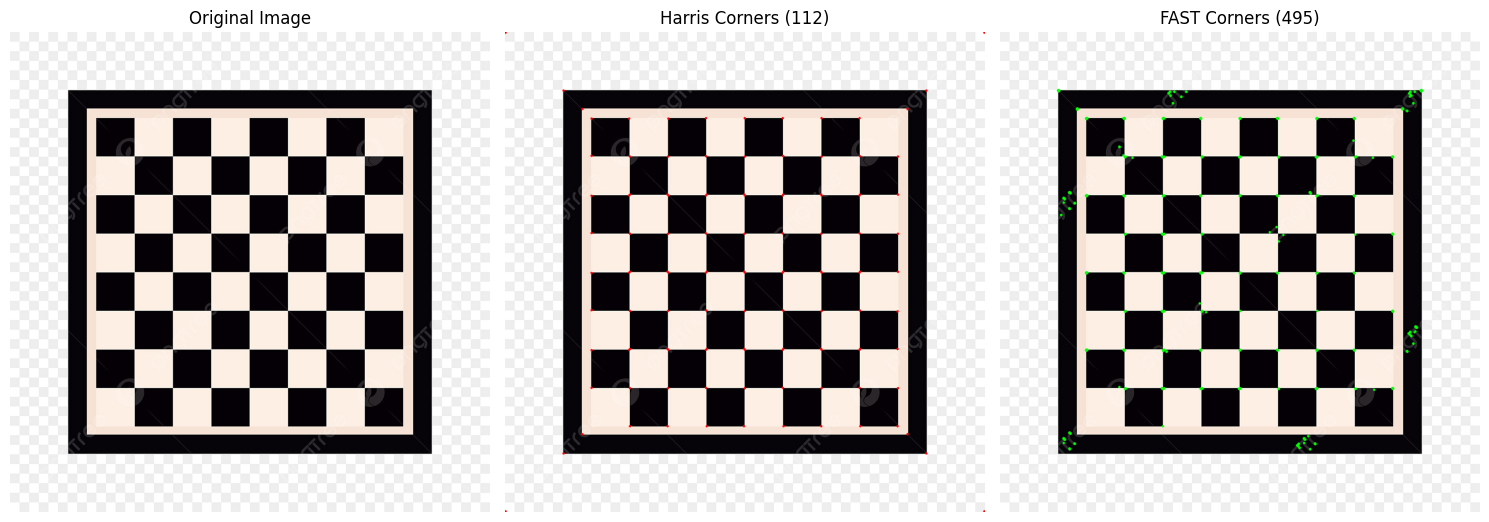

In [ ]:
def main():
    # -------------------- IMAGE LOADING --------------------

    img_path = "chessboard.jpg"
    # Path to input image (chessboard has strong, clear corners)

    # img_path = "sudoku.jpg"
    # img_path = "building.jpg"
    # Alternative images that also contain corners


    original = cv2.imread(img_path)

    if original is None:
        print("Error: Could not load image. Please check the file path.")
        return


    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    

    # -------------------- HARRIS DETECTION --------------------

    print("Running Harris Corner Detector (from scratch)...")

    harris_pts = harris_corners_from_scratch(
        gray.astype(np.float32),

        block_size=3,        
        ksize=3,            
        k=0.04,               # Harris detector constant controlling sensitivity
        threshold_ratio=0.01
                               # Relative threshold to keep strong corner responses
    )


    # -------------------- FAST DETECTION --------------------

    print("Running FAST Corner Detector (from scratch)...")
    # Prints status message

    fast_pts = fast_corners_from_scratch(
        gray,
        # FAST works directly on uint8 grayscale image
        threshold=30,
        n=9
        # Minimum number of contiguous pixels for FAST-9 detector
    )


    # -------------------- VISUALIZATION: HARRIS --------------------

    img_harris = original.copy()

    for y, x in harris_pts:
        cv2.circle(img_harris, (x, y), 3, (0, 0, 255), -1)
        # Draws a red filled circle at each Harris corner location


    # -------------------- VISUALIZATION: FAST --------------------

    img_fast = original.copy()

    for y, x in fast_pts:
        cv2.circle(img_fast, (x, y), 3, (0, 255, 0), -1)
        # Draws a green filled circle at each FAST corner location


    # -------------------- DISPLAY RESULTS --------------------

    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 3, 2) # Creates second subplot for Harris output
    plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
    # Displays image with Harris corners

    plt.title(f"Harris Corners ({len(harris_pts)})")
    # Shows number of detected Harris corners

    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_fast, cv2.COLOR_BGR2RGB))
    plt.title(f"FAST Corners ({len(fast_pts)})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()



# -------------------- PROGRAM ENTRY POINT --------------------

if __name__ == "__main__":
    # Ensures main() runs only when this script is executed directly

    main()
    # Calls the main function
